In [1]:
from collections.abc import Sequence
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import skimage
from desmin_reconstruction.plotting.lineplots import line_and_bandplot
from desmin_reconstruction.utils.array import midpoints
from einops import rearrange
from tqdm import tqdm
from jaxtyping import Float, Bool, Shaped, Int

pv.set_jupyter_backend("static")

datadir = Path("../data/SIM")


COLOR_DICT = {"desmin": "#FF0000", "actinin": "#00FF00", "actin": "#0000FF"}
LABEL_DICT = {"desmin": "Desmin", "actin": "Actin", "actinin": "α-actinin"}


def read_SIM_data(filepath: Path | str):
    f = h5py.File(filepath)
    data = f["Data"][:]
    pixel_sizes = f["Data"].attrs["pixel_sizes"]
    dtype = data.dtype
    if dtype.kind == "u":
        data = data / np.iinfo(dtype).max
    return data, pixel_sizes


In [2]:
data_full, pixel_sizes = read_SIM_data(datadir / "alpha-actinin/Image2_SIM2.h5")
print(pixel_sizes)
data = data_full[:, 0:12, 2000 - 768 : 2000, 0:768]
data.shape

[0.12593877 0.01565149 0.01565149]


(2, 12, 768, 768)

In [3]:
grids_subset = []
img_data = rearrange(data, "C Z Y X->C X Y Z")
for img_channel in img_data:
    grid = pv.ImageData(
        dimensions=np.array(img_channel.shape) + 1,
        spacing=pixel_sizes[::-1],
        # origin=(bbox.x0, bbox.y0, 0),
    )
    grid.cell_data["data"] = img_channel.flatten(order="F")
    grids_subset.append(grid)

2026-06-15 19:30:41.679 (   7.195s) [    14C944D92740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


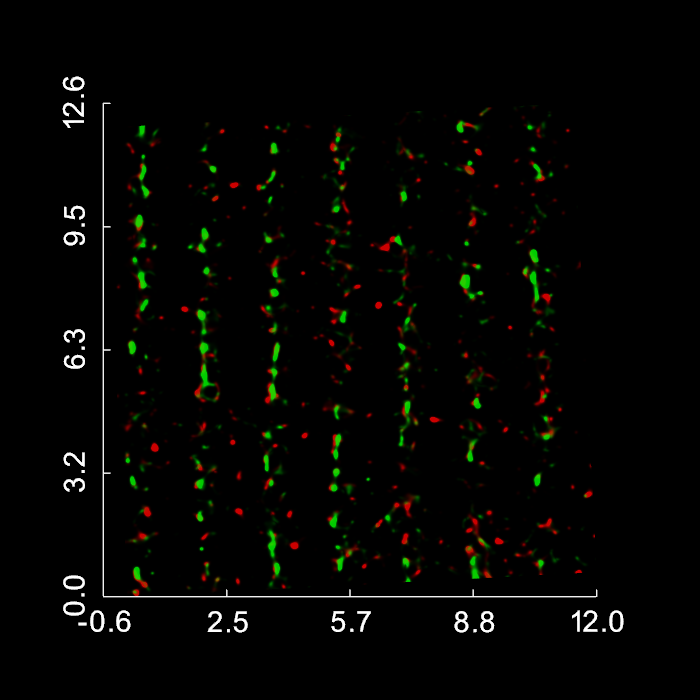

In [4]:
pl = pv.Plotter(notebook=True, window_size=(700, 700))
pl.subplot(0, 0)
actor = pl.add_volume(
    grids_subset[0].rotate_z(3),
    cmap=["#FF0000"],
    opacity=[0.0, 0.2, 0.8],
    clim=(0, 0.2),
    blending="maximum",
    show_scalar_bar=False,
)
actor.prop.interpolation_type = "linear"
actor = pl.add_volume(
    grids_subset[1].rotate_z(3),
    cmap=["#00FF00"],
    opacity=[0.0, 0.2, 0.8],
    clim=(0, 0.2),
    # opacity_unit_distance=1.5,
    blending="maximum",
    show_scalar_bar=False,
)
actor.prop.interpolation_type = "linear"
pl.set_background(color="black")
pl.enable_parallel_projection()

pl.view_xy()
axis = pl.show_bounds(
    color="white",
    # axes_ranges=[0, 16, 0, 16, 0, 0],
    grid=None,
    bold=False,
    font_size=22,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    xtitle="",
    ytitle="",
    ztitle="",
)
pl.show()
# pl.save_graphic("../figures/fig_4/4b/overlay_xy.svg")

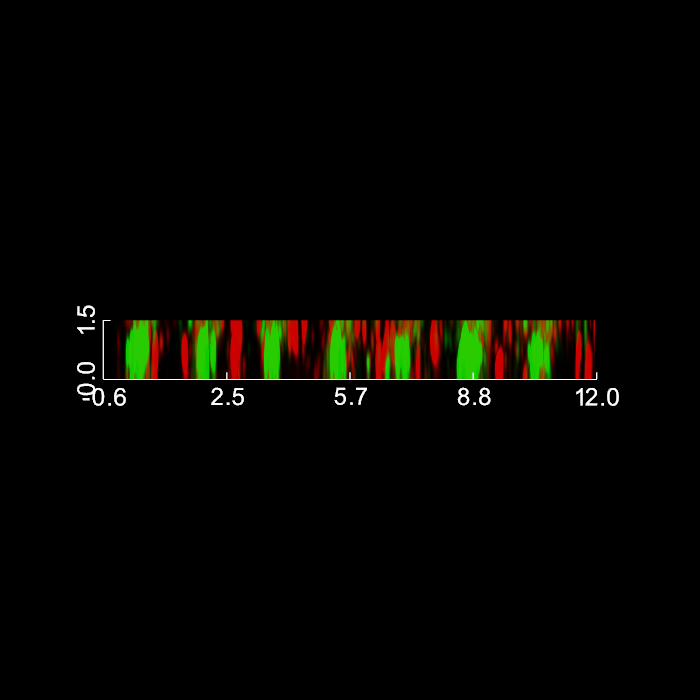

In [5]:
pl = pv.Plotter(notebook=True, window_size=(700, 700))
actor = pl.add_volume(
    grids_subset[0].rotate_z(3),
    cmap=["#FF0000"],
    opacity=[0.0, 0.2, 0.8],
    clim=(0, 0.20),
    blending="maximum",
    show_scalar_bar=False,
)
actor.prop.interpolation_type = "linear"
actor = pl.add_volume(
    grids_subset[1].rotate_z(3),
    cmap=["#00FF00"],
    opacity=[0.0, 0.2, 0.8],
    clim=(0, 0.20),
    # opacity_unit_distance=1.5,
    blending="maximum",
    show_scalar_bar=False,
)
actor.prop.interpolation_type = "linear"
pl.set_background(color="black")
pl.enable_parallel_projection()

pl.view_xz()
axis = pl.show_bounds(
    color="white",
    # axes_ranges=[0, 16, 0, 16, 0, 0],
    grid=None,
    bold=False,
    font_size=22,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    n_zlabels=2,
    xtitle="",
    ytitle="",
    ztitle="",
)
pl.show()
# pl.save_graphic("../figures/fig_4/4b/overlay_xz.svg")

In [6]:
data.shape

(2, 12, 768, 768)

In [7]:
kernel_size = (data[0].shape[0] // 10, data[0].shape[1] // 5, data[0].shape[2] // 5)
print(kernel_size)
data = [
    skimage.exposure.equalize_adapthist(d, kernel_size, np.percentile(d.flatten(), 99))
    for d in data
]


(1, 153, 153)


In [8]:
z_ind = 5  # 0:12
img_orig = data[1][z_ind]

In [9]:
img_orig.shape

(768, 768)

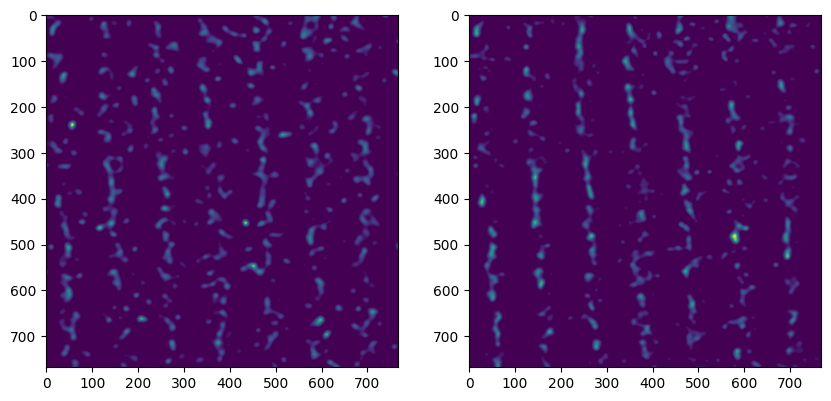

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
for i, ax in enumerate(axes):
    ax.imshow(data[i][z_ind])

In [11]:
def detect_Z_lines(
    img: Float[np.ndarray, "X Y"],
    blur_sigma: tuple[int, int] = (40, 5),
    ridge_sigmas: int | Sequence[int] = range(15, 20),
    lower_thres_ratio: float = 0.4,
) -> tuple[Bool[np.ndarray, "X Y"], dict[str, Shaped[np.ndarray, "X Y"]]]:
    blurred = skimage.filters.gaussian(img, blur_sigma)
    ridges = skimage.filters.sato(blurred, sigmas=ridge_sigmas, black_ridges=False)
    thres = skimage.filters.threshold_otsu(ridges)
    binarized = skimage.filters.apply_hysteresis_threshold(
        ridges, lower_thres_ratio * thres, thres
    )
    skele = skimage.morphology.medial_axis(binarized)

    metadata = {"blurred": blurred, "ridges": ridges, "binarized": binarized}
    return skele, metadata

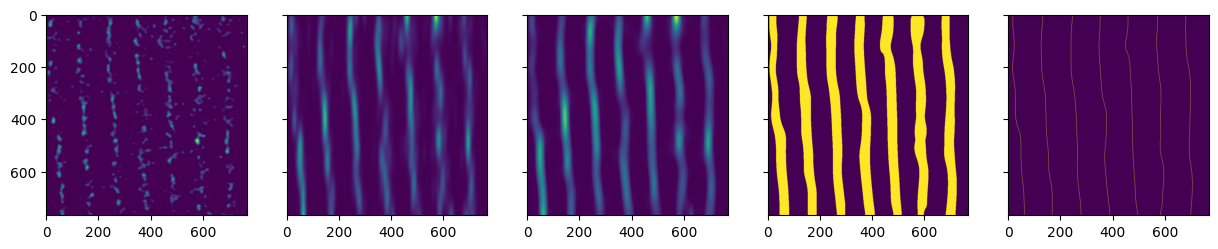

In [12]:
skele, metadata = detect_Z_lines(img_orig)

fig, axes = plt.subplots(1, 5, figsize=(15, 6), sharex=True, sharey=True)
axes[0].imshow(img_orig)
axes[1].imshow(metadata["blurred"])
axes[2].imshow(metadata["ridges"])
axes[3].imshow(metadata["binarized"])
axes[4].imshow(skele)

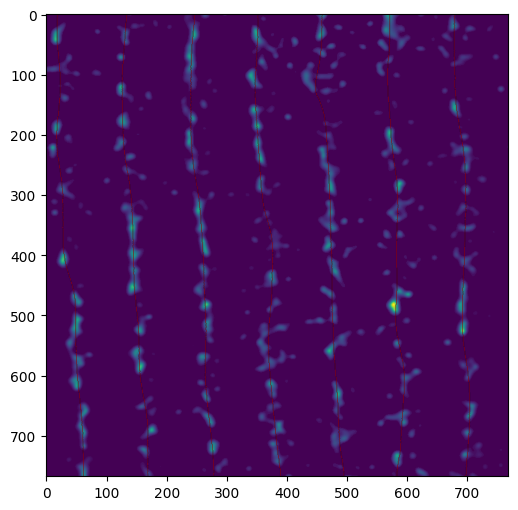

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.imshow(
    img_orig,
)
ax.imshow(np.ma.masked_where(skele == 0, skele), alpha=0.9, cmap="autumn")

In [14]:
def binarize_z_slice(z_slice):
    bin = z_slice >= skimage.filters.threshold_otsu(z_slice)
    return skimage.morphology.binary_opening(bin, skimage.morphology.disk(3))

In [15]:
import scipy.ndimage as scndimage


dists = scndimage.distance_transform_edt(np.logical_not(skele))
binar_actinin = binarize_z_slice(data[1][z_ind])
binar_desmin = binarize_z_slice(data[0][z_ind])

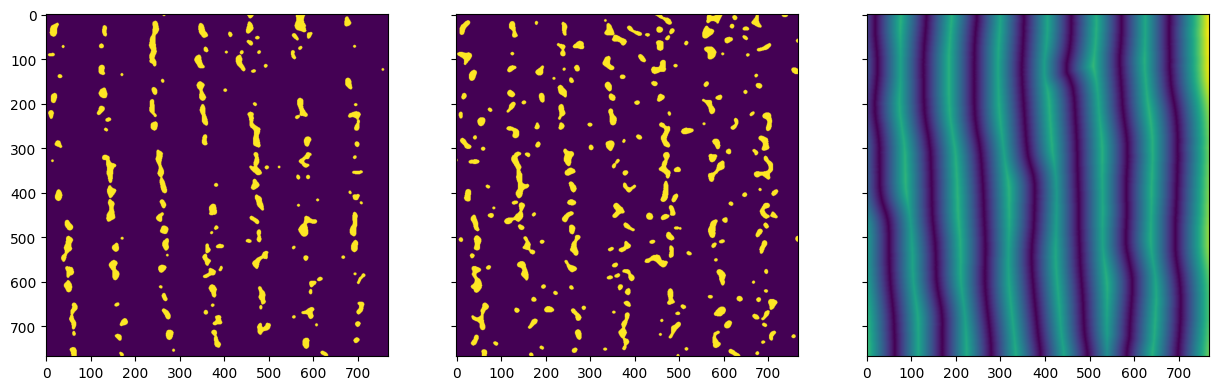

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True, sharey=True)
axes[2].imshow(dists)
axes[0].imshow(binar_actinin)
axes[1].imshow(binar_desmin)

In [17]:
def connected_to_boundary(region: Bool[np.ndarray, "X Y"], axis: int = 0) -> bool:
    """For a binary array indicating a segmented object and the background, determine
    if the object touches the image boundary along axis.

    This is done by projecting the region along the axis of interest, then checking
    both ends of the projected binary array."""
    projection = np.any(region, axis=axis)
    return projection[0] or projection[-1]


def filter_outliers(
    x: Float[np.ndarray, " N"], lower=0.5, higher: float = 1.5
) -> Float[np.ndarray, " M"]:
    median = np.nanmedian(x)
    return x[np.logical_and(x > 0.5 * median, x < 1.5 * median)]


def estimate_mean_sarcomere_width(
    z_lines: Bool[np.ndarray, "X Y"],
) -> tuple[Float[np.ndarray, ""], Int[np.ndarray, "X Y"]]:
    """Given a binary array marking the Z line positions, estimate the mean width of the
    sarcomeres in the image.

    Assumes that the Z lines are oriented along the Y axis, dividing the imaged region
    into banded partitions. Some imperfects in the Z lines are tolerated, as too wide or
    too narrow regions are excluded during averaging."""

    region_ids, num_regions = skimage.measure.label(
        z_lines, background=True, connectivity=1, return_num=True
    )
    widths = []
    for i in range(1, num_regions + 1):
        region = region_ids == i
        if not connected_to_boundary(region, axis=0):
            widths.append(np.mean(np.sum(region, axis=1)))
    return np.mean(filter_outliers(np.asarray(widths))), region_ids

In [18]:
width, labeled = estimate_mean_sarcomere_width(skele)
width

np.float64(108.38606770833333)

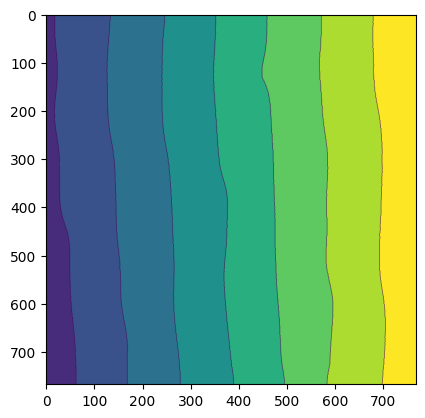

In [19]:
plt.imshow(labeled)

In [20]:
dists = []
desmin_weights = []
actinin_weights = []
sarco_widths = []
for z_ind in tqdm(range(12)):
    slice_desmin, slice_actinin = data[0][z_ind], data[1][z_ind]
    z_lines = detect_Z_lines(slice_actinin)[0]

    for roi_ind in range(9):
        z_lines_roi = rearrange(z_lines, "(Ny Y) (Nx X) -> (Ny Nx) Y X", Ny=3, Nx=3)[
            roi_ind
        ]

        desmin_roi = rearrange(
            slice_desmin, "(Ny Y) (Nx X) -> (Ny Nx) Y X", Ny=3, Nx=3
        )[roi_ind]
        actinin_roi = rearrange(
            slice_actinin, "(Ny Y) (Nx X) -> (Ny Nx) Y X", Ny=3, Nx=3
        )[roi_ind]

        sarco_width = estimate_mean_sarcomere_width(z_lines_roi)[0]
        sarco_widths.append(sarco_width)
        z_dists = scndimage.distance_transform_edt(
            np.logical_not(z_lines_roi)
        )  # / sarco_width
        dists.append(z_dists.flatten())
        desmin_weights.append(
            (np.ones_like(desmin_roi) * binarize_z_slice(desmin_roi)).flatten()
        )
        actinin_weights.append(
            (np.ones_like(actinin_roi) * binarize_z_slice(actinin_roi)).flatten()
        )
    # desmin_weights.append(binarize_z_slice(slice_desmin).flatten())
    # actinin_weights.append(binarize_z_slice(slice_actinin).flatten())


  0%|          | 0/12 [00:00<?, ?it/s]/home/jhko725/projects/desmin_reconstruction/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jhko725/projects/desmin_reconstruction/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 12/12 [00:46<00:00,  3.84s/it]


In [21]:
sarco_width_all = rearrange(np.asarray(sarco_widths), "(Z ROI) -> ROI Z", Z=12)
sarco_width_all

array([[221.1484375 , 221.20703125, 110.59375   , 110.47851562,
        110.21679688, 109.9609375 , 109.63476562, 109.29296875,
        108.84570312, 108.59375   , 108.69726562, 108.66015625],
       [104.66015625, 104.66015625, 104.6875    , 105.03125   ,
        105.734375  , 107.25390625, 109.19140625, 110.68359375,
        111.6875    , 111.59765625, 110.55859375, 109.796875  ],
       [109.09765625, 109.36328125, 109.73828125, 110.18359375,
        110.78515625, 111.1328125 , 111.07421875, 110.88671875,
        112.04296875, 113.4609375 , 114.80859375, 116.13671875],
       [107.89453125, 107.96875   , 108.27734375, 108.60546875,
        109.09765625, 109.48828125, 109.44140625, 108.9375    ,
        108.16015625, 107.37109375, 106.49609375, 106.73828125],
       [102.8125    , 103.00390625, 103.28515625, 103.3515625 ,
        103.140625  , 103.09375   , 103.21875   , 103.4921875 ,
        104.12109375, 104.65234375, 105.0625    , 107.2734375 ],
       [110.328125  , 110.19921875,

In [74]:
sarco_width_total = [np.mean(filter_outliers(s)) for s in sarco_width_all]
dists_total = rearrange(np.asarray(dists), "(Z ROI) N -> ROI (Z N)", Z=12)
desmin_total = rearrange(np.asarray(desmin_weights), "(Z ROI) N -> ROI (Z N)", Z=12)
actinin_total = rearrange(np.asarray(actinin_weights), "(Z ROI) N -> ROI (Z N)", Z=12)

desmin_counts = [
    np.histogram(d / s, bins=np.linspace(0, 0.5, 25), weights=w, density=True)[0]
    for d, w, s in zip(dists_total, desmin_total, sarco_width_total)
]
actinin_counts = [
    np.histogram(d / s, bins=np.linspace(0, 0.5, 25), weights=w, density=True)[0]
    for d, w, s in zip(dists_total, actinin_total, sarco_width_total)
]

(0.0, 15.5)

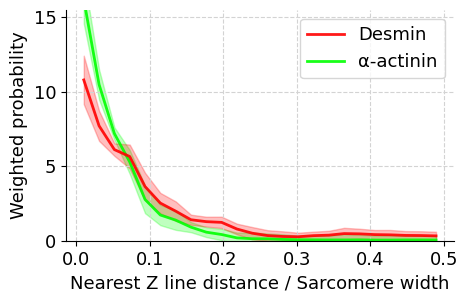

In [76]:
plt.rc("font", size=13)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax = line_and_bandplot(
    ax,
    midpoints(np.linspace(0, 0.5, 25)),
    np.mean(actinin_counts, axis=0),
    np.std(desmin_counts, axis=0),
    color=COLOR_DICT["actinin"],
    linewidth=2.0,
    label=LABEL_DICT["actinin"],
    alpha=0.9,
    alpha_band=0.25,
)

ax = line_and_bandplot(
    ax,
    midpoints(np.linspace(0, 0.5, 25)),
    np.mean(desmin_counts, axis=0),
    np.std(desmin_counts, axis=0),
    color=COLOR_DICT["desmin"],
    linewidth=2.0,
    label=LABEL_DICT["desmin"],
    alpha=0.9,
    alpha_band=0.25,
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(ls="--", color="lightgray")
ax.set_xlabel("Nearest Z line distance / Sarcomere width")
ax.set_ylabel("Weighted probability")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1])
ax.set_ylim((0.0, 15.5))
# fig.savefig("../figures/fig_4/4c.svg", dpi=500, bbox_inches="tight")

In [22]:
dists = []
desmin_weights = []
actinin_weights = []
for z_ind in tqdm(range(12)):
    slice_desmin, slice_actinin = data[0][z_ind], data[1][z_ind]
    z_lines = detect_Z_lines(slice_actinin)[0]
    sarco_width = estimate_mean_sarcomere_width(z_lines)[0]

    print(z_ind, sarco_width)
    z_dists = (
        scndimage.distance_transform_edt(np.logical_not(z_lines)) / sarco_width
    )  # / sarco_width
    dists.append(z_dists.flatten())
    desmin_weights.append(
        (np.ones_like(slice_desmin) * binarize_z_slice(slice_desmin)).flatten()
    )
    actinin_weights.append(
        (np.ones_like(slice_actinin) * binarize_z_slice(slice_actinin)).flatten()
    )
    # desmin_weights.append(binarize_z_slice(slice_desmin).flatten())
    # actinin_weights.append(binarize_z_slice(slice_actinin).flatten())


  8%|▊         | 1/12 [00:03<00:42,  3.83s/it]

0 107.33626302083334


 17%|█▋        | 2/12 [00:07<00:38,  3.83s/it]

1 107.3681640625


 25%|██▌       | 3/12 [00:11<00:34,  3.83s/it]

...

9 108.30490451388887


 92%|█████████▏| 11/12 [00:42<00:03,  3.83s/it]

10 108.28515625


100%|██████████| 12/12 [00:45<00:00,  3.83s/it]

11 108.34700520833333


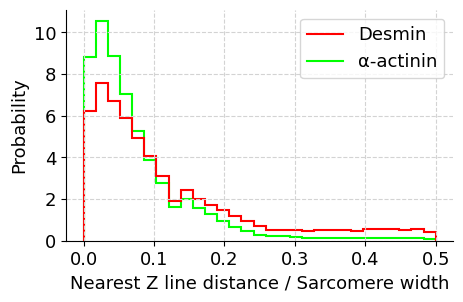

In [23]:
plt.rc("font", size=13)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.stairs(
    *np.histogram(
        np.concatenate(dists, axis=0),
        bins=np.linspace(0, 0.5, 30),
        weights=np.concatenate(actinin_weights, axis=0),
        density=True,
    ),
    color=COLOR_DICT["actinin"],
    linewidth=1.5,
    label=LABEL_DICT["actinin"],
)

ax.stairs(
    *np.histogram(
        np.concatenate(dists, axis=0),
        bins=np.linspace(0, 0.5, 30),
        weights=np.concatenate(desmin_weights, axis=0),
        density=True,
    ),
    color=COLOR_DICT["desmin"],
    linewidth=1.5,
    label=LABEL_DICT["desmin"],
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(ls="--", color="lightgray")
ax.set_xlabel("Nearest Z line distance / Sarcomere width")
ax.set_ylabel("Probability")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1])
fig.savefig("../figures/fig_4/4c.svg", dpi=500, bbox_inches="tight")